In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import config
import worldcover_api as wc
import worldcover_utils as wu
import numpy as np



In [2]:
west,south,east,north=(float(x) for x in config.BBOX_CHIANG_MAI.split(","))
print(f"bbox: west={west}, south={south}, east={east}, north={north}")

tiles=wc.tiles_for_bbox(west,south,east,north)
print(f"\n{len(tiles)} tiles needed: {tiles}")

bbox: west=98.0, south=17.0, east=100.0, north=20.0

4 tiles needed: ['N15E096', 'N15E099', 'N18E096', 'N18E099']


In [3]:
with wc.open_tile(tiles[0]) as src:
    print("Shape (rows, cols):", src.shape)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print(f"Transform: \n{src.transform}")
    print("Dtype:", src.dtypes)

Shape (rows, cols): (36000, 36000)
CRS: EPSG:4326
Bounds: BoundingBox(left=96.0, bottom=15.0, right=99.0, top=18.0)
Transform: 
| 0.00, 0.00, 96.00|
| 0.00,-0.00, 18.00|
| 0.00, 0.00, 1.00|
Dtype: ('uint8',)


In [4]:
data,transform=wc.read_window(tiles[0],(west,south,east,north),year=2021)
print("Shape after windowed read:", data.shape)
print("Land cover codes present:", sorted(set(np.unique(data).tolist())))

Shape after windowed read: (5477, 3651)
Land cover codes present: [10, 20, 30, 40, 50, 60, 80, 90]


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'WorldCover 2021 - N15E096 (partial bbox)'}, xlabel='column (pixel)', ylabel='row (pixel)'>)

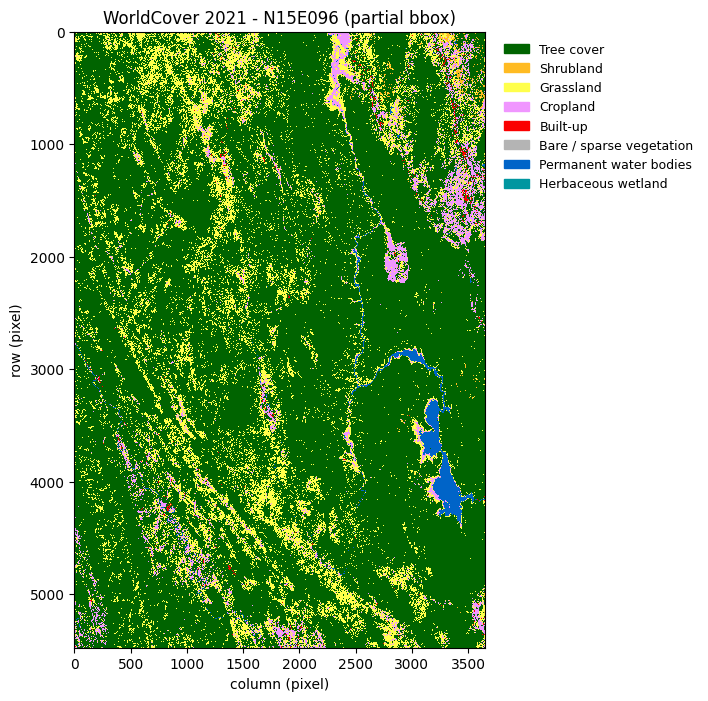

In [5]:
wu.plot_landcover(data,title=f"WorldCover 2021 - {tiles[0]} (partial bbox)")

In [6]:
SAMPLE_LAT,SAMPLE_LON=18.5,99.0
result=wu.sample_landcover(SAMPLE_LAT,SAMPLE_LON,year=2021)
print(result)

{'code': 40, 'class_name': 'Cropland', 'color': '#f096ff'}


In [7]:
stats=wu.landcover_stats(data)
stats

,code,class,pixels,percent
0,10,Tree cover,15972629,79.88
1,30,Grassland,2935385,14.68
2,40,Cropland,764862,3.82
3,80,Permanent water bodies,222796,1.11
4,20,Shrubland,48673,0.24
5,50,Built-up,46059,0.23
6,60,Bare / sparse vegetation,5797,0.03
7,90,Herbaceous wetland,326,0.00


Shape after full mosaic: (5477, 3651)


(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'WorldCover 2021 - Chiang Mai (all 4 tiles merged)'}, xlabel='column (pixel)', ylabel='row (pixel)'>)

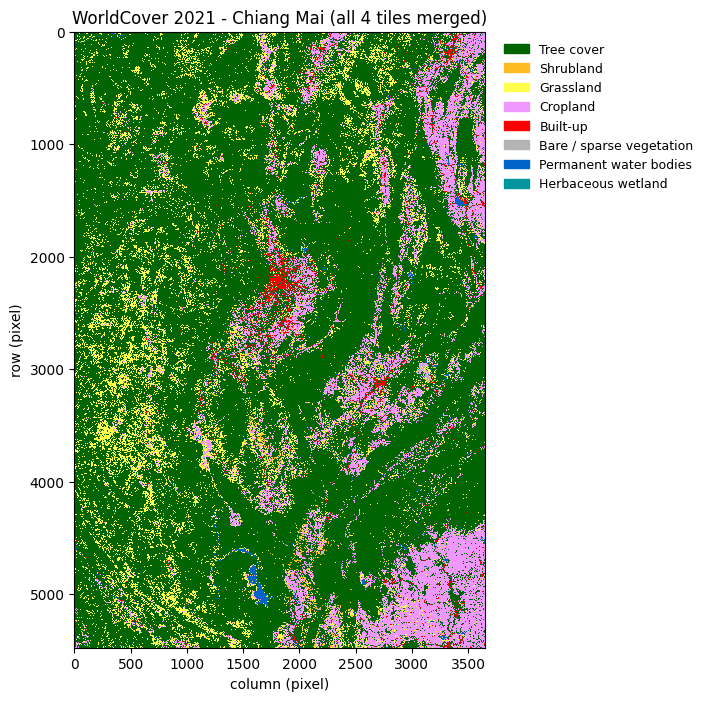

In [8]:
mosaic,mosaic_transform=wc.mosaic_tiles(tiles,(west,south,east,north),year=2021)
print("Shape after full mosaic:", mosaic.shape)
wu.plot_landcover(mosaic,title="WorldCover 2021 - Chiang Mai (all 4 tiles merged)")

In [9]:
stats_full=wu.landcover_stats(mosaic)
stats_full

,code,class,pixels,percent
0,10,Tree cover,15128576,75.66
1,40,Cropland,2287390,11.44
2,30,Grassland,2105994,10.53
3,50,Built-up,269607,1.35
4,80,Permanent water bodies,98275,0.49
5,20,Shrubland,80333,0.40
6,60,Bare / sparse vegetation,20757,0.10
7,0,Unknown (0),5477,0.03
8,90,Herbaceous wetland,118,0.00


In [10]:
try:
    wc.download_worldcover((100,17,98,20))
except ValueError as e:
    print("[OK]",e)

[OK] Wrong order: west must be LESS THAN east (west,south,east,north)


In [11]:
try:
    wc.download_worldcover((98,17,100,20),year=2019)
except ValueError as e:
    print("[OK]",e)

[OK] year must be one of [2020, 2021], got 2019


In [12]:
result=wc.download_worldcover((west,south,east,north),year=2021) 
if result is not None:
    data_full,transform_full=result
    print("Shape:",data_full.shape)

Area needs 4 tile(s): ['N15E096', 'N15E099', 'N18E096', 'N18E099']
[downloaded] worldcover_2021_98p0_17p0_100p0_20p0.tif - shape (5477, 3651)
Shape: (5477, 3651)
